In [1]:
!git clone https://github.com/shaheenshaik799/duplicate-of-mini.git


Cloning into 'duplicate-of-mini'...
remote: Enumerating objects: 7387, done.
remote: Total 7387 (delta 0), reused 0 (delta 0), pack-reused 7387 (from 1)
Receiving objects: 100% (7387/7387), 1.15 GiB | 42.22 MiB/s, done.
Resolving deltas: 100% (1234/1234), done.
Updating files: 100% (11741/11741), done.


In [2]:
%cd duplicate-of-mini

/content/duplicate-of-mini


In [3]:
!ls


baseline_model.pth  evaluate.py  requirements.txt  step3_defence.py
dataset		    models	 ste1_model.py	   train.py
defense_model.pth   __pycache__  step2_attack.py   utils.py


In [4]:
!pip install torch torchvision
!pip install matplotlib seaborn pandas numpy

In [5]:
import os

dataset_path = "/content/duplicate-of-mini/dataset/train"

for cls in os.listdir(dataset_path):
    print(cls, len(os.listdir(os.path.join(dataset_path, cls))))

NORMAL 1341
PNEUMONIA 3875


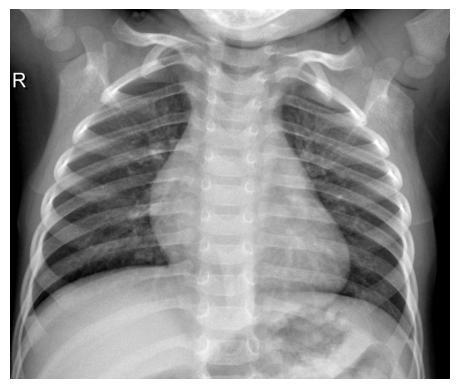

In [6]:
import cv2
import matplotlib.pyplot as plt

img_path = "/content/duplicate-of-mini/dataset/train/NORMAL"

img = cv2.imread(os.path.join(img_path, os.listdir(img_path)[0]))

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [7]:
print(img.shape)

(1148, 1364, 3)


In [8]:
img_resized = cv2.resize(img,(224,224))

In [9]:
img_normalized = img_resized / 255.0

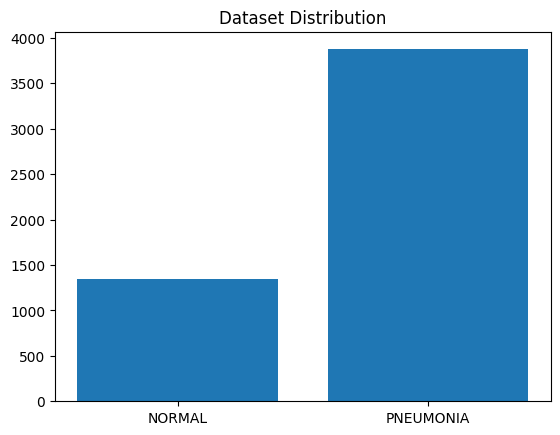

In [10]:
classes=[]
counts=[]

for cls in os.listdir(dataset_path):
    classes.append(cls)
    counts.append(len(os.listdir(os.path.join(dataset_path,cls))))

plt.bar(classes,counts)
plt.title("Dataset Distribution")
plt.show()

In [11]:
from PIL import Image

for cls in os.listdir(dataset_path):
    folder = os.path.join(dataset_path,cls)

    for file in os.listdir(folder):
        try:
            img = Image.open(os.path.join(folder,file))
        except:
            print("Corrupted:",file)